In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# check out the data

In [44]:
!ls data/

current_foreground_noise_model.dat  foreground_noise_model.dat
current_instrument_noise_model.dat  full_noise_model.dat
current_sgwb_noise_model.dat        instrument_noise_model.dat
dft_data.dat                        power_data.dat
final_foreground_noise_model.dat    power_noise_reconstruction.dat
final_full_noise_model.dat          sgwb_noise_model.dat
final_instrument_noise_model.dat    whitened_data.dat
final_sgwb_noise_model.dat


In [45]:
power_data = np.loadtxt('data/power_data.dat')
full_noise = np.loadtxt('data/full_noise_model.dat')

In [4]:
# cols are f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [4]:
full_noise.shape

(20250, 7)

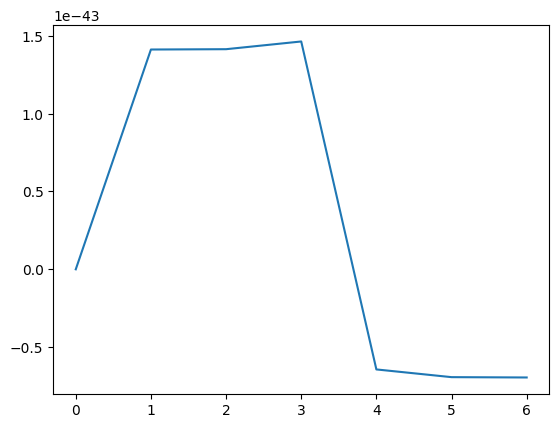

In [46]:
plt.plot(full_noise[19000,:])

In [ ]:
# time array for wavelets


In [47]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline
def wavelet_specgram(t, f, pz, Nt = 512):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    cmap = 'bwr'
    z = pz.copy()
    z /= z.max()
    norm = colors.Normalize(vmin=z.min(), vmax = z.max())
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    plt.pcolormesh(t[:Nt], f[::Nt], z.reshape((Nf,Nt)),cmap=cmap,norm=norm,shading='auto',snap=True, rasterized=True)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

In [48]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2])

Nt or Nf is wrong


ValueError: cannot reshape array of size 20250 into shape (39,512)

# check out the chains

In [4]:
sgwb = np.loadtxt('chains/sgwb_chain.dat')#, max_rows=700)

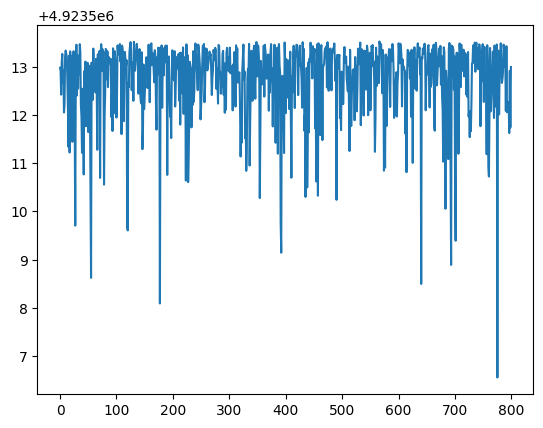

In [5]:
plt.plot(sgwb[200:,1])

In [6]:
from corner import corner

In [7]:
sgwb_chain = np.array(
    [
        sgwb[:,2], # logA
        sgwb[:,3], # alpha
    ]).T
sgwb_labels = [r'$\log A$', r'$\alpha$']

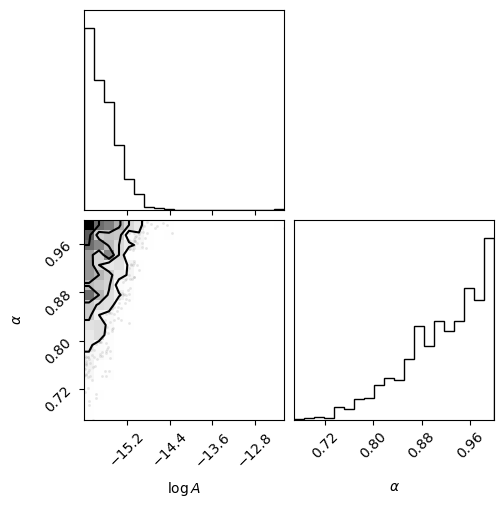

In [8]:
corner(sgwb_chain, labels = sgwb_labels)
plt.show()

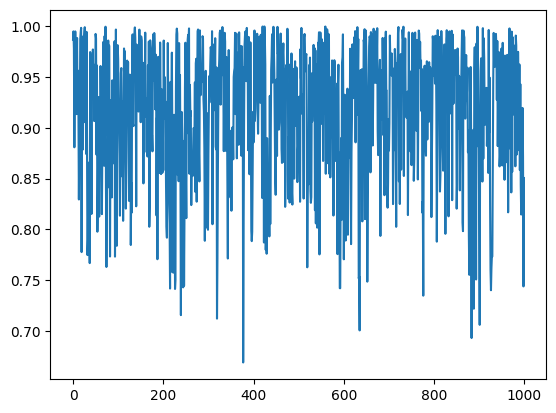

In [9]:
plt.plot(sgwb_chain[:,1])